# Notebook 04 — Optimisation des hyperparamètres et du seuil métier

## Objectif

Partir du modèle gagnant identifié au notebook 03 (LightGBM natif, AUC = 0.7699) et l'améliorer sur deux axes :

1. **Hyperparamètres** — optimisation avec Optuna pour trouver la meilleure configuration
2. **Seuil de décision** — optimisation basée sur une fonction de coût métier où un faux négatif (défaut non détecté) coûte 10× plus qu'un faux positif (bon client refusé)

Le tracking MLflow est maintenu pour comparer le modèle optimisé au baseline du notebook 03.

In [2]:
pip install optuna

  Obtaining dependency information for optuna from https://files.pythonhosted.org/packages/ac/24/7c731839566d30dc70556d9824ef17692d896c15e3df627bce8c16f753e1/optuna-4.8.0-py3-none-any.whl.metadata
  Obtaining dependency information for colorlog from https://files.pythonhosted.org/packages/6d/c1/e419ef3723a074172b68aaa89c9f3de486ed4c2399e2dbd8113a4fdcaf9e/colorlog-6.10.1-py3-none-any.whl.metadata
  Obtaining dependency information for tqdm from https://files.pythonhosted.org/packages/16/e1/3079a9ff9b8e11b846c6ac5c8b5bfb7ff225eee721825310c91b3b50304f/tqdm-4.67.3-py3-none-any.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 14.1 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use update

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import optuna
import mlflow
import mlflow.lightgbm
import sys
sys.path.append('..')

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, recall_score, precision_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

from src.utils import clean_application, overview, reduce_memory

import warnings
warnings.filterwarnings('ignore')

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
# Charger les données enrichies 
train = pd.read_csv('../data/processed/train_featured.csv')
reduce_memory(train)

# Séparer X et y
y = train['TARGET']
X = train.drop(columns=['TARGET', 'SK_ID_CURR'])

# Identifier les colonnes par type
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include='number').columns.tolist()

# Convertir les catégorielles en type 'category' (LightGBM natif)
for col in cat_cols:
    X[col] = X[col].astype('category')

print(f"Shape : {X.shape}")
print(f"Features numériques : {len(num_cols)}")
print(f"Features catégorielles : {len(cat_cols)}")
print(f"Répartition TARGET :\n{y.value_counts(normalize=True).round(4)}")

Mémoire : 624.3 Mo → 427.8 Mo (31% de réduction)
Shape : (307505, 145)
Features numériques : 129
Features catégorielles : 16
Répartition TARGET :
TARGET
0    0.9193
1    0.0807
Name: proportion, dtype: float64


---
## 2. Fonction de coût métier

### Contexte business

Dans le cadre de l'octroi de crédit, les erreurs n'ont pas le même impact :

- **Faux positif (FP)** : un bon client est refusé → perte commerciale (opportunité manquée)
- **Faux négatif (FN)** : un client défaillant est accepté → perte financière (crédit non remboursé)

Le coût d'un FN est estimé à **10× celui d'un FP**. La fonction de coût à minimiser est :

$$coût = 1 \times FP + 10 \times FN$$

### Conséquence sur le seuil de décision

Par défaut, un modèle classe "défaut" si la probabilité prédite > 0.5. Avec cette asymétrie de coût, on veut **baisser le seuil** pour détecter davantage de défauts, quitte à refuser plus de bons clients. L'objectif est de trouver le seuil qui minimise le coût total.

In [8]:
def business_cost(y_true, y_pred, cost_fp=1, cost_fn=10):
    """
    Calcule le coût métier basé sur la matrice de confusion.
    
    Parameters
    ----------
    y_true : array-like — classes réelles (0 ou 1)
    y_pred : array-like — classes prédites (0 ou 1)
    cost_fp : int — coût d'un faux positif (bon client refusé)
    cost_fn : int — coût d'un faux négatif (défaut non détecté)
    
    Returns
    -------
    float — coût total
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return cost_fp * fp + cost_fn * fn


# Vérification rapide avec des valeurs fictives
y_test_demo = np.array([0, 0, 0, 1, 1])
y_pred_demo = np.array([0, 1, 0, 0, 1])  # 1 FP, 1 FN

cost = business_cost(y_test_demo, y_pred_demo)
print(f"Demo — FP: 1, FN: 1 → Coût: {cost}")
print(f"Le FN pèse {10}× plus que le FP dans le coût total")

Demo — FP: 1, FN: 1 → Coût: 11
Le FN pèse 10× plus que le FP dans le coût total


---
## 3. Optimisation des hyperparamètres avec Optuna

### Pourquoi optimiser avant le seuil ?

Les hyperparamètres contrôlent comment le modèle apprend (profondeur des arbres, vitesse d'apprentissage, régularisation...). Ils influencent directement la qualité des probabilités prédites. Le seuil, lui, opère sur ces probabilités. Il est donc logique d'abord optimiser le modèle, puis d'ajuster le seuil.

### Stratégie

- **Modèle** : LightGBM natif 
- **Méthode** : Optuna (recherche bayésienne)
- **Métrique d'optimisation** : AUC (mesure la qualité globale du ranking, indépendante du seuil)
- **Validation** : StratifiedKFold 5 folds 
- **Paramètre fixe** : `is_unbalance=True` (traitement du déséquilibre conservé)

In [9]:
# Validation croisée 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    """Fonction objectif pour Optuna — retourne l'AUC moyenne en CV."""
    
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        # Paramètres fixes
        'is_unbalance': True,
        'random_state': 42,
        'verbose': -1,
    }
    
    scores = []
    for train_idx, val_idx in cv.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model = lgb.LGBMClassifier(**params)
        model.fit(X_train, y_train)
        
        y_proba = model.predict_proba(X_val)[:, 1]
        scores.append(roc_auc_score(y_val, y_proba))
    
    return np.mean(scores)

# Optimisation
study = optuna.create_study(direction='maximize', study_name='lgbm_optimization')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nMeilleure AUC : {study.best_value:.4f}")
print(f"Baseline NB03 : 0.7699")
print(f"Gain : {study.best_value - 0.7699:+.4f}")
print(f"\nMeilleurs hyperparamètres :")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best trial: 48. Best value: 0.773354: 100%|██████████| 50/50 [27:31<00:00, 33.03s/it]


Meilleure AUC : 0.7734
Baseline NB03 : 0.7699
Gain : +0.0035

Meilleurs hyperparamètres :
  n_estimators: 350
  max_depth: 10
  learning_rate: 0.04617037503904527
  num_leaves: 39
  min_child_samples: 107
  subsample: 0.6725206217098281
  colsample_bytree: 0.7032849849782064
  reg_alpha: 0.2997094004463088
  reg_lambda: 4.430207742291048


In [10]:
# Entraîner le modèle final avec les meilleurs hyperparamètres
best_params = study.best_params
best_params.update({
    'is_unbalance': True,
    'random_state': 42,
    'verbose': -1,
})

best_model = lgb.LGBMClassifier(**best_params)
best_model.fit(X, y)

# Obtenir les probabilités en cross-validation (pour l'optimisation du seuil)
y_proba_cv = cross_val_predict(
    lgb.LGBMClassifier(**best_params),
    X, y, cv=cv, method='predict_proba'
)[:, 1]

print(f"AUC CV : {roc_auc_score(y, y_proba_cv):.4f}")

AUC CV : 0.7733


---
## 4. Optimisation du seuil de décision

### Principe

Par défaut, le modèle classe un client comme "défaillant" si sa probabilité prédite dépasse 0.5. Mais avec un coût FN 10× supérieur au coût FP, ce seuil par défaut n'est pas optimal.

On va tester une grille de seuils entre 0.05 et 0.95, calculer le coût métier pour chacun, et retenir celui qui minimise le coût total.

In [11]:
# Tester une grille de seuils
thresholds = np.arange(0.05, 0.95, 0.01)

results = []
for t in thresholds:
    y_pred_t = (y_proba_cv >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, y_pred_t).ravel()
    cost = business_cost(y, y_pred_t)
    results.append({
        'threshold': t,
        'cost': cost,
        'fp': fp,
        'fn': fn,
        'tp': tp,
        'tn': tn,
        'recall': recall_score(y, y_pred_t),
        'precision': precision_score(y, y_pred_t),
        'f1': f1_score(y, y_pred_t),
    })

df_thresholds = pd.DataFrame(results)

# Trouver le seuil optimal
best_row = df_thresholds.loc[df_thresholds['cost'].idxmin()]
print(f"Seuil optimal : {best_row['threshold']:.2f}")
print(f"Coût minimal  : {best_row['cost']:.0f}")
print(f"Recall         : {best_row['recall']:.4f}")
print(f"Precision      : {best_row['precision']:.4f}")
print(f"F1             : {best_row['f1']:.4f}")
print(f"FP : {best_row['fp']:.0f}  |  FN : {best_row['fn']:.0f}")
print(f"\n--- Comparaison avec le seuil par défaut (0.5) ---")
default_row = df_thresholds.loc[(df_thresholds['threshold'] - 0.5).abs().idxmin()]
print(f"Coût à 0.5     : {default_row['cost']:.0f}")
print(f"Économie       : {default_row['cost'] - best_row['cost']:.0f} ({(default_row['cost'] - best_row['cost']) / default_row['cost'] * 100:.1f}%)")

Seuil optimal : 0.52
Coût minimal  : 155886
Recall         : 0.6408
Precision      : 0.1925
F1             : 0.2961
FP : 66706  |  FN : 8918

--- Comparaison avec le seuil par défaut (0.5) ---
Coût à 0.5     : 155964
Économie       : 78 (0.1%)


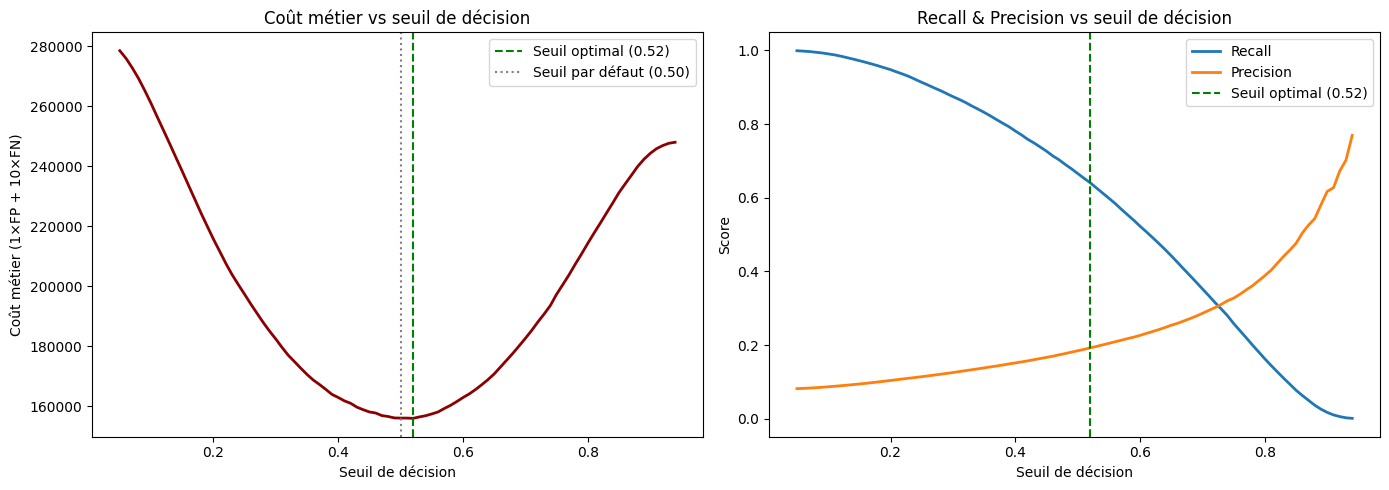

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Coût métier en fonction du seuil
axes[0].plot(df_thresholds['threshold'], df_thresholds['cost'], color='darkred', linewidth=2)
axes[0].axvline(x=best_row['threshold'], color='green', linestyle='--', 
                label=f"Seuil optimal ({best_row['threshold']:.2f})")
axes[0].axvline(x=0.5, color='gray', linestyle=':', label='Seuil par défaut (0.50)')
axes[0].set_xlabel('Seuil de décision')
axes[0].set_ylabel('Coût métier (1×FP + 10×FN)')
axes[0].set_title('Coût métier vs seuil de décision')
axes[0].legend()

# Graphique 2 : Recall et Precision en fonction du seuil
axes[1].plot(df_thresholds['threshold'], df_thresholds['recall'], label='Recall', linewidth=2)
axes[1].plot(df_thresholds['threshold'], df_thresholds['precision'], label='Precision', linewidth=2)
axes[1].axvline(x=best_row['threshold'], color='green', linestyle='--', 
                label=f"Seuil optimal ({best_row['threshold']:.2f})")
axes[1].set_xlabel('Seuil de décision')
axes[1].set_ylabel('Score')
axes[1].set_title('Recall & Precision vs seuil de décision')
axes[1].legend()

plt.tight_layout()
plt.show()

L'optimisation Optuna a amélioré l'AUC de +0.0035 (0.7699 → 0.7734). Le seuil optimal (0.52) est quasi identique au défaut (0.50), avec un gain de coût négligeable (0.1%)

---
## 5. Évaluation finale — Baseline vs Modèle optimisé

Comparaison du modèle LightGBM natif avant et après optimisation (hyperparamètres + seuil).

In [14]:
# Tableau comparatif baseline vs optimisé
comparison = pd.DataFrame({
    'Baseline (NB03)': {
        'Hyperparamètres': 'Défaut',
        'Seuil': 0.50,
        'AUC': 0.7699,
        'Recall': 0.6683,
        'Precision': 0.2151,
        'F1': 0.3256,
        'Coût métier': '-',
    },
    'Optimisé (NB04)': {
        'Hyperparamètres': 'Optuna (50 trials)',
        'Seuil': best_row['threshold'],
        'AUC': roc_auc_score(y, y_proba_cv),
        'Recall': best_row['recall'],
        'Precision': best_row['precision'],
        'F1': best_row['f1'],
        'Coût métier': best_row['cost'],
    }
})
print(comparison.to_string())

                Baseline (NB03)     Optimisé (NB04)
Hyperparamètres          Défaut  Optuna (50 trials)
Seuil                       0.5                0.52
AUC                      0.7699            0.773348
Recall                   0.6683            0.640765
Precision                0.2151            0.192548
F1                       0.3256            0.296115
Coût métier                   -            155886.0


In [15]:
# Calculer le coût baseline (seuil 0.5 avec le modèle NB03)
# On utilise le modèle optimisé au seuil 0.5 comme proxy
y_pred_default = (y_proba_cv >= 0.50).astype(int)
cost_default = business_cost(y, y_pred_default)
print(f"Coût métier baseline (seuil 0.5) : {cost_default}")
print(f"Coût métier optimisé (seuil 0.52) : {int(best_row['cost'])}")
print(f"Économie : {cost_default - int(best_row['cost'])}")

Coût métier baseline (seuil 0.5) : 155964
Coût métier optimisé (seuil 0.52) : 155886
Économie : 78


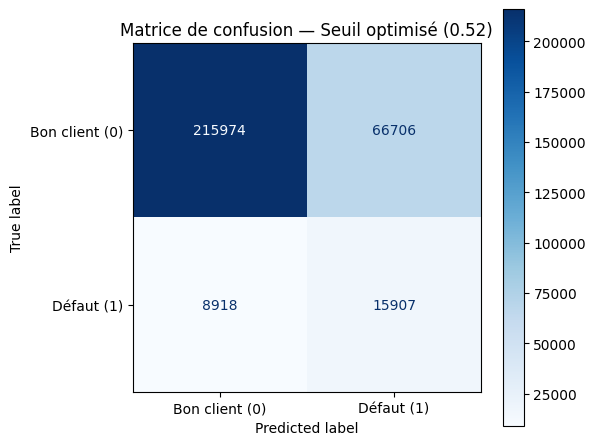


Sur 24825 vrais défaillants, le modèle en détecte 15907 (64.1%) et en rate 8918 (35.9%)


In [17]:
# Matrice de confusion au seuil optimal
y_pred_optimal = (y_proba_cv >= best_row['threshold']).astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y, y_pred_optimal,
    display_labels=['Bon client (0)', 'Défaut (1)'],
    cmap='Blues',
    ax=ax
)
ax.set_title(f"Matrice de confusion — Seuil optimisé ({best_row['threshold']:.2f})")
plt.tight_layout()
plt.show()

print(f"\nSur {int(best_row['fn'] + best_row['tp'])} vrais défaillants, "
      f"le modèle en détecte {int(best_row['tp'])} ({best_row['recall']:.1%}) "
      f"et en rate {int(best_row['fn'])} ({1 - best_row['recall']:.1%})")

---
## 6. Tracking MLflow et conclusion

In [22]:
mlflow.set_tracking_uri("file:../mlruns")
mlflow.set_experiment("home-credit-default-risk")

with mlflow.start_run(run_name="07_LightGBM_optuna_optimized"):
    
    # Paramètres
    mlflow.log_param("model", "LightGBM")
    mlflow.log_param("nan_strategy", "native")
    mlflow.log_param("class_balance", "is_unbalance=True")
    mlflow.log_param("n_features", len(num_cols) + len(cat_cols))
    mlflow.log_param("optimal_threshold", best_row['threshold'])
    mlflow.log_param("n_trials_optuna", 50)
    
    # Hyperparamètres Optuna
    for k, v in study.best_params.items():
        mlflow.log_param(k, round(v, 6) if isinstance(v, float) else v)
    
    # Métriques
    mlflow.log_metric("AUC_mean", roc_auc_score(y, y_proba_cv))
    mlflow.log_metric("Recall_mean", best_row['recall'])
    mlflow.log_metric("F1_mean", best_row['f1'])
    mlflow.log_metric("Precision_mean", best_row['precision'])
    mlflow.log_metric("business_cost", best_row['cost'])
    mlflow.log_metric("FP", best_row['fp'])
    mlflow.log_metric("FN", best_row['fn'])
    
    # Tags
    mlflow.set_tag("phase", "hyperparameter_optimization")
    mlflow.set_tag("author", "Fatih")
    mlflow.set_tag("optimization", "Optuna 50 trials")
    
    # Modèle
    mlflow.lightgbm.log_model(best_model, "model")
    
    print("Run MLflow loggé avec succès.")

2026/04/10 12:28:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 12:28:57 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run MLflow loggé avec succès.


### Conclusion du Notebook 04

**Hyperparamètres (Optuna)** :
- 50 trials, ~27 minutes de calcul
- Gain AUC : +0.0035 (0.7699 → 0.7734)

**Seuil de décision** :
- Seuil optimal : 0.52 (quasi identique au défaut 0.50)
- Gain de coût : négligeable (0.1%)

**Bilan des runs MLflow** :

| Run | Modèle | AUC | Recall | Coût métier |
|-----|--------|-----|--------|-------------|
| 04 (NB03) | LightGBM natif — défaut | 0.7699 | 0.6683 | 155 964 |
| 07 (NB04) | LightGBM natif — Optuna | 0.7734 | 0.6408 | 155 886 |